In [1]:
import yaml
import jax.numpy as jnp
from ajx import Transform
from panda3d.core import loadPrcFileData

loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

import numpy as np
from PIL import Image
from IPython.display import display

import jax

jax.config.update("jax_enable_x64", True)

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
from ajx.constraints import ConstraintType
from ajx.example_environments.dlo import DLO, DLOSettings, CableParameters#, LockedDLO
from ajx.simulation import SimulationSettings, Solver
import jax.numpy as jnp
import ajx.math as math
from ajx import Transform

#print(dir(DLO))




An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
timestep = 1/60
grippermc_to_marker = jnp.array([0.0478024, 0, 0])

states = []
with open("marker_data/real_dlo_marker_data.yaml", "r") as stream:
    data_loaded = yaml.safe_load(stream)

gripper_com_to_marker = jnp.array(data_loaded["gripper_com_to_marker"])
env = DLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=50,
        length=data_loaded["length"],
        radius=data_loaded["radius"],
        density=data_loaded["mass"] / (data_loaded["length"]*data_loaded["radius"]**2*np.pi),
        pose_estimate_linear_offsets=data_loaded["marker_displacements"],
        gripper1_offset=Transform(gripper_com_to_marker, math.Rotations.unitary),
        gripper2_offset=Transform(-gripper_com_to_marker, math.Rotations.unitary),
        loose_end=False,
    ),
)

nu = 0.333
E = 1e7
cable_param = CableParameters(
    youngs_modulus=E,
    shear_modulus=E / (2 * (1 + nu)),
    damping=env.default_param.sparse_param.cable_param.damping,
)

env_param = env.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)

for sample_name, marker_pose in data_loaded["marker_poses"].items():

    # 1. build marker transforms for THIS frame
    marker_transform_list = []
    for site_name, pose in marker_pose.items():
        marker_transform_list.append(
            Transform(
                jnp.array(pose["pos"]),
                jnp.array(pose["rot"])
            )
        )

    marker_transforms = Transform.stack(marker_transform_list)

    # 2. convert to body + frame
    body_transforms = env.convert_marker_transforms_to_body_transforms(marker_transforms)

    frame_transforms = env.convert_body_transforms_to_frame_transforms(
        env_param, body_transforms
    )

    # 3. build state
    state = env.get_state_by_interface_interpolation(
        env_param,
        [frame_transforms[0], frame_transforms[1], body_transforms]
    )

    # 4. store it
    states.append(state)

state0 = states[0]
state_end = states[8]

print("num segments:", state0.conf.pos.shape[0])
print("first segment:", state0.conf.pos[0])
print("last segment:", state0.conf.pos[-1])

print("num segments :", state_end.conf.pos.shape[0])
print("first segment:", state_end.conf.pos[0])
print("last segment:", state_end.conf.pos[-1])





#recreate state from data

sample_name = list(data_loaded["marker_poses"].keys())[0] #Initial poses or first at least
marker_pose = data_loaded["marker_poses"][sample_name]

num segments: 56
first segment: [ 0.39996122  0.75089094 -0.07157084]
last segment: [-0.43528563  0.73219339 -0.09501347]
num segments : 56
first segment: [ 0.34076451  0.74584945 -0.11203206]
last segment: [-0.37669233  0.73533289 -0.13406551]


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
Xlib:  extension "XFree86-DGA" missing on display ":0".
:device(error): Error adding inotify watch on /dev/input: No such file or directory
:device(error): Error opening directory /dev/input: No such file or directory
AL lib: (WW) pulse_load: Failed to load libpulse.so.0
AL lib: (WW) alc_initconfig: Failed to initialize backend "pulse"
AL lib: (WW) alsa_load: Failed to load libasound.so.2
AL lib: (WW) alc_initconfig: Failed to initialize backend "alsa"
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
:audio(error): Couldn't open default OpenAL device
:audio(error): OpenALAudioManager: No open device or context
:audio(error):   OpenALAudioManager is not 

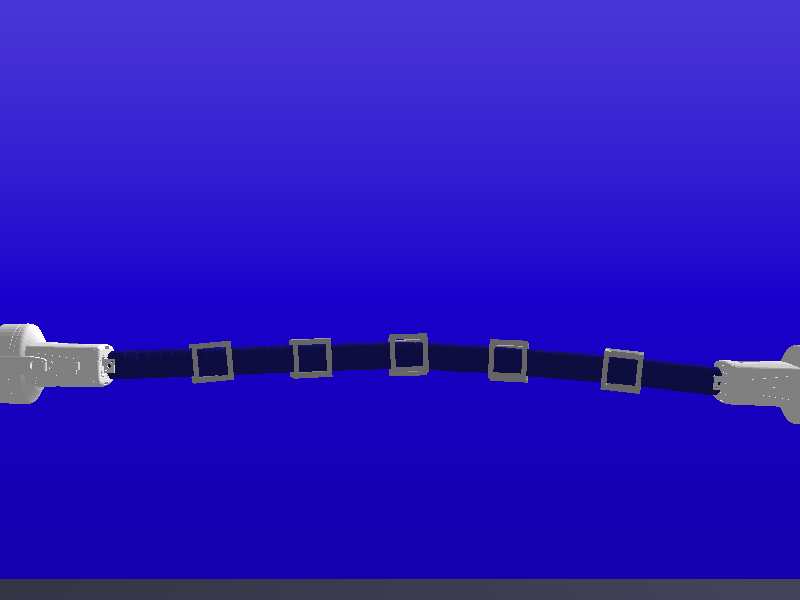

In [3]:
env.camera_rot = math.quat_from_axis_angle(jnp.array([0.0, 0.0, 1.0]), jnp.pi)
scene = EnvironmentScene(env, env_param, states[0], show_text=False, show_fps=False, debug_render=False)
# 1. kill old app safely
try:
    app.destroy()
except:
    pass
    
try:
    del scene
except:
    pass

# 2. rebuild scene from scratch
scene = EnvironmentScene(env, env_param, states[0],
                         show_text=False,
                         show_fps=False,
                         debug_render=False)


# 3. create fresh app
app = Application(scene, 60, "default", headless=True)

# 4. render
scene.update_geometry()
img = app.get_headless_frame()
display(img)

In [5]:
import imageio
from IPython.display import Video

writer = imageio.get_writer("animation.mp4", fps=5)  # slower since only 9 frames

frames = []

for state in states:
    scene.state = state
    scene.update_geometry()

    app.graphicsEngine.renderFrame()
    frame = app.get_headless_frame()

    writer.append_data(np.array(frame))

writer.close()

Video("animation.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [19]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State, GeneralizedVelocity
from ajx.example_environments.dlo import DLOState
target_pose = state.conf
lock_targets = state.lock_targets
start_err = jnp.linalg.norm(state.gvel.data)
env = environment
n_bodies = env.env_settings.n_segments

def forward_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+6, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    next_state = env.step_state(state, jnp.zeros([12]), param)
    return next_state.gvel.data.flatten()

def inverse_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+6, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)
    return force.flatten()

residual = inverse_dynamics_residual
jac_r = tangent_jacfwd(residual)

def gauss_newton(x0, n_iter, damping):
    x = x0
    for i in range(n_iter):
        rx = residual(x)
        J = jac_r(x) 

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)

        x = x.retract(delta)
        print(f"Iter: {i}\t |rx|: {jnp.linalg.norm(rx)}")
    return x, J



# Pretend that stiffness is unknown
env_param = env.default_param.tree_replace(src={
    "sparse_param.cable_param.youngs_modulus":  1e4,
    "sparse_param.cable_param.shear_modulus":  1e4,
})

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

# Optimize
solution, Js = gauss_newton(env_param, n_iter=50, damping=0.0)
print(jnp.linalg.cond(Js))


Iter: 0	 |rx|: 0.2620482087724165
Iter: 1	 |rx|: 1.4134398196935313e-06
Iter: 2	 |rx|: 1.413439819653103e-06
Iter: 3	 |rx|: 1.4134398196530832e-06
Iter: 4	 |rx|: 1.413439819653103e-06
Iter: 5	 |rx|: 1.4134398196531272e-06
Iter: 6	 |rx|: 1.413439819653103e-06
Iter: 7	 |rx|: 1.4134398196530832e-06
Iter: 8	 |rx|: 1.413439819653103e-06
Iter: 9	 |rx|: 1.4134398196531272e-06
Iter: 10	 |rx|: 1.413439819653103e-06
Iter: 11	 |rx|: 1.4134398196530832e-06
Iter: 12	 |rx|: 1.413439819653103e-06
Iter: 13	 |rx|: 1.4134398196531272e-06
Iter: 14	 |rx|: 1.413439819653103e-06
Iter: 15	 |rx|: 1.4134398196530832e-06
Iter: 16	 |rx|: 1.413439819653103e-06
Iter: 17	 |rx|: 1.4134398196531272e-06
Iter: 18	 |rx|: 1.413439819653103e-06
Iter: 19	 |rx|: 1.4134398196530832e-06
Iter: 20	 |rx|: 1.413439819653103e-06
Iter: 21	 |rx|: 1.4134398196531272e-06
Iter: 22	 |rx|: 1.413439819653103e-06
Iter: 23	 |rx|: 1.4134398196530832e-06
Iter: 24	 |rx|: 1.413439819653103e-06
Iter: 25	 |rx|: 1.4134398196531272e-06
Iter: 26	 |r

In [20]:
# Print results
youngs_modulus = solution.sparse_param.cable_param.youngs_modulus
shear_modulus = solution.sparse_param.cable_param.shear_modulus
poissons_ratio = youngs_modulus / (2 * shear_modulus) - 1
print(f"Poisson's ratio: {poissons_ratio}")
print(
    f"Youngs modulus, shear modulus: \t{youngs_modulus}, {shear_modulus}"
)

# Estimate uncertainty
U, S, V = jnp.linalg.svd(Js)

JTJ_inv = V @ jnp.diag((1/(S+1e-16))**2) @ V.T
residual_sample_variance = jnp.linalg.norm(residual(solution))**2 / (residual(solution).shape[0] - env_param.tangent_size())
cov = JTJ_inv * residual_sample_variance
parameter_std = jnp.sqrt(jnp.diag(cov))
print(f"Standard deviation estimate: \t\t{parameter_std[:3]}")

Poisson's ratio: 0.33299884346610464
Youngs modulus, shear modulus: 	9999990.188833857, 3750937.3087044754
Standard deviation estimate: 		[ 2.95491017 14.66724994]


Marker error: 1.988765008579603e-32


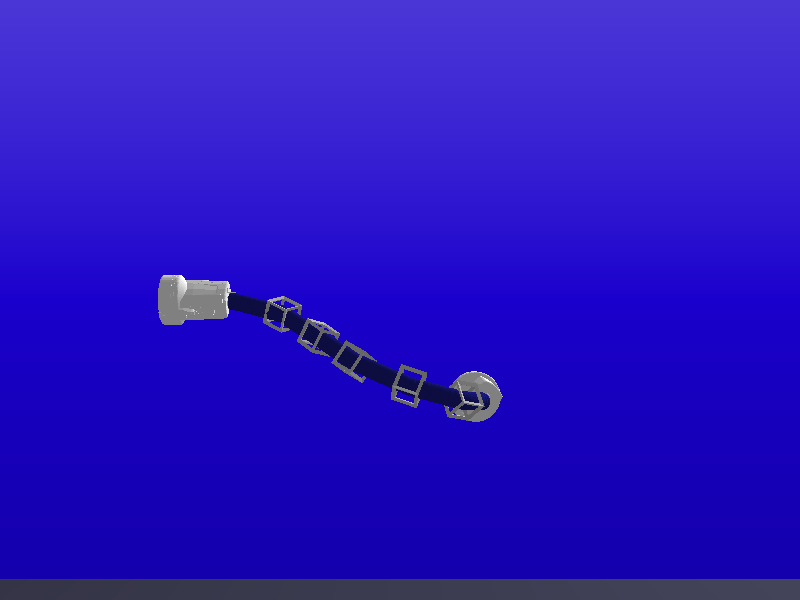

In [21]:
n_confs = len(observations)
marker_transforms = Transform(
    observations.reshape(-1,7)[:,:3],
    observations.reshape(-1,7)[:,3:],
)
concat_pose = jnp.stack(observations)

body_transforms = env.convert_marker_transforms_to_body_transforms(
    marker_transforms
)
frame_transforms = env.convert_body_transforms_to_frame_transforms(
    env_param, body_transforms
)
state = env.get_state_by_interface_interpolation(
    env_param, [frame_transforms[0], frame_transforms[1], body_transforms]
)

# Ensure the state is aligned with the marker poses
n_poses = len(env.sim.sensor_list)
observed_marker_poses_flat = env.observe_state(state, jnp.zeros(12), env_param)
observed_marker_poses_arr = observed_marker_poses_flat.reshape(n_poses, 7)
observed_marker_poses = Transform(observed_marker_poses_arr[:,:3], observed_marker_poses_arr[:,3:])
marker_residual = jax.vmap(Transform.log_map)(observed_marker_poses, marker_transforms)
squared_error = jnp.sum(marker_residual**2)
print(f"Marker error: {squared_error}")

scene.state = state
scene.update_geometry()
img = app.get_headless_frame()
display(img)